## Conditional Workflow 2

In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field

In [2]:
load_dotenv()  # Load environment variables from .env file

True

In [3]:
model = ChatOpenAI(model="gpt-4o-mini")

In [8]:
class SentimentSchema(BaseModel):
    sentiment: Literal["positive", "negative"] = Field(description="The sentiment of the review")


In [15]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [16]:
structured_model = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)

In [24]:
prompt = "what is the sentiment of this review: 'I love this product! It works great and exceeded my expectations.'?"

result = structured_model.invoke(prompt)

In [7]:
class ReviewState(TypedDict):

    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str

In [10]:
def find_sentiment(state:ReviewState):

    prompt = f'for the following review find out the sentiment \n {state["review"]}'
    sentiment = structured_model.invoke(prompt).sentiment

    return {'sentiment' : sentiment}

In [22]:
# condition function
def check_sentiment(state: ReviewState) -> Literal["positive_response","run_diagnosis"]:

    if state['sentiment'] == 'positive':
        return "positive_response"

    else:
        return "run_diagnosis"

def positive_response(state: ReviewState):

    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
Also, kindly ask the user to leave feedback on our website."""

    response = model.invoke(prompt).content
    return {'response' : response}

def run_diagnosis(state: ReviewState):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""
    response = structured_model2.invoke(prompt)

    return {'diagnosis': response.model_dump()}

def negetive_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content

    return {'response': response}



In [23]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment',find_sentiment)
graph.add_node('positive_response',positive_response)
graph.add_node('run_diagnosis',run_dignosis)
graph.add_node('negetive_response',negetive_response)

graph.add_edge(START,'find_sentiment')
graph.add_conditional_edges('find_sentiment',check_sentiment)
graph.add_edge('positive_response',END)
graph.add_edge('run_diagnosis','negetive_response')
graph.add_edge('negetive_response',END)


workflow = graph.compile()

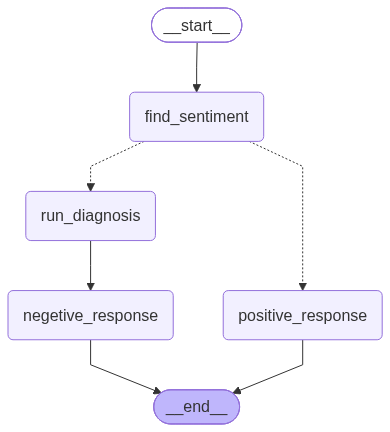

In [24]:
workflow

In [14]:
initial_state = {
    'review' : 'I hate this product!'
}

workflow.invoke(initial_state)

{'review': 'I hate this product!', 'sentiment': 'negative'}

In [25]:


intial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
workflow.invoke(intial_state)



{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'response': "Subject: We're Here to Help You with the Bug Issue\n\nHi [User's Name],\n\nI completely understand how frustrating it can be to encounter a bug, especially when it disrupts your work. Thank you for bringing this to our attention, and I want to assure you that we are here to help you resolve it as quickly as possible.\n\nCould you please provide a bit more detail about the issue you're experiencing? Information such as when the bug occurs, any error messages you see, and the steps you took leading up to the problem can be incredibly helpful in diagnosing the issue.\n\nIn the meantime, I recommend trying to restart the application 